# TPOSE Model Velocity Spectra

Computes and compares depth-resolved PSD of TPOSE-Vel and TPOSE-noVel at three equatorial TAO mooring longitudes.  
**Layout:** 3 rows (170W, 140W, 110W) × 3 columns (TPOSE-Vel | TPOSE-noVel | log₁₀ ratio)  
**Variables:** U and V computed separately  
**Depths:** 0–300 m  
**Period range:** ≥5 days (daily model output; Nyquist = 2 days)

In [1]:
import sys
import os
sys.path.insert(0, '/home/edavenport/analysis/vel-assim-manuscript')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.signal import welch
import cmocean.cm as cmo
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.size'] = 13

OUTDIR = '/home/edavenport/analysis/vel-assim-manuscript/assimilation_results/spectra'

# Welch parameters (daily data, fs=1 cpd)
FS       = 1.0   # cycles per day
NPERSEG  = 128   # ~half the 275-day record -> ~3 overlapping segments
NOVERLAP = 64

# Locations: (longitude_East, label)
LOCS = [(190, '0°N 170°W'), (220, '0°N 140°W'), (250, '0°N 110°W')]

## Load TPOSE-noVel

In [2]:
import pickle

CACHE_FILE = os.path.join(OUTDIR, 'psd_cache.pkl')

if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE, 'rb') as f:
        psd_results = pickle.load(f)
    print(f'Loaded cache: {CACHE_FILE}')
    for var in psd_results:
        for lon_E in psd_results[var]:
            res = psd_results[var][lon_E]
            print(f'  {var} {res["label"]}: {len(res["depths"])} depths, {len(res["freqs"])} freq bins')
else:
    print('No cache found — loading data and computing PSDs...')

    # --- Load TPOSE-noVel ---
    from open_tpose import tpose2012to2013
    prefix = ['diag_state']
    ds_noVel = tpose2012to2013(prefix)
    for c in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds_noVel[c] = ds_noVel[c].astype(float)
    print('TPOSE-noVel time:', ds_noVel.time.values[[0, -1]])

    # --- Load TPOSE-Vel ---
    from xmitgcm import open_mdsdataset
    grid_dir  = '/data/SO6/TPOSE_diags/tpose6/grid_6/'
    offset    = 10
    itPerFile = 72

    data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_assim/run_iter22/'
    num_diags = 30 + 31 + offset
    intervals = range(itPerFile, itPerFile * num_diags, itPerFile)
    ds = open_mdsdataset(data_dir=data_dir, grid_dir=grid_dir, iters=intervals,
                         prefix=prefix, ref_date='2012-09-01', delta_t=1200)

    data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
    num_diags = 30 + 31 + offset
    intervals = range(itPerFile * offset, itPerFile * num_diags, itPerFile)
    ds_new = open_mdsdataset(data_dir=data_dir, grid_dir=grid_dir, iters=intervals,
                              prefix=prefix, ref_date='2012-11-01', delta_t=1200)
    ds_Vel = xr.concat([ds, ds_new], dim='time')

    data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
    num_diags = 31 + 28 + offset
    intervals = range(itPerFile * offset, itPerFile * num_diags, itPerFile)
    ds_new = open_mdsdataset(data_dir=data_dir, grid_dir=grid_dir, iters=intervals,
                              prefix=prefix, ref_date='2013-01-01', delta_t=1200)
    ds_Vel = xr.concat([ds_Vel, ds_new], dim='time')

    data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
    num_diags = 31 + 30 + 31 + 30
    intervals = range(itPerFile * offset, itPerFile * num_diags, itPerFile)
    ds_new = open_mdsdataset(data_dir=data_dir, grid_dir=grid_dir, iters=intervals,
                              prefix=prefix, ref_date='2013-03-01', delta_t=1200)
    ds_Vel = xr.concat([ds_Vel, ds_new], dim='time')

    for c in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds_Vel[c] = ds_Vel[c].astype(float)
    print('TPOSE-Vel time:', ds_Vel.time.values[[0, -1]], '| N steps:', len(ds_Vel.time))

    # --- Compute Welch PSDs ---
    VAR_MAP = {
        'U': ('UVEL', 'XG', 'YC'),
        'V': ('VVEL', 'XC', 'YG'),
    }
    psd_results = {}
    for var, (varname, xdim, ydim) in VAR_MAP.items():
        psd_results[var] = {}
        for lon_E, label in LOCS:
            da_noVel = (ds_noVel[varname]
                        .sel({xdim: lon_E}, method='nearest')
                        .sel({ydim: 0},     method='nearest')
                        .compute())
            da_Vel = (ds_Vel[varname]
                      .sel({xdim: lon_E}, method='nearest')
                      .sel({ydim: 0},     method='nearest')
                      .compute())
            da_noVel = da_noVel.sel(Z=da_noVel.Z[da_noVel.Z >= -300])
            da_Vel   = da_Vel.sel(Z=da_Vel.Z[da_Vel.Z >= -300])

            depths = da_noVel.Z.values
            n_d    = len(depths)
            freqs, _ = welch(da_noVel.isel(Z=0).values, fs=FS,
                             nperseg=NPERSEG, noverlap=NOVERLAP,
                             window='hann', detrend='linear')
            n_f = len(freqs)
            psd_noVel_arr = np.zeros((n_d, n_f))
            psd_Vel_arr   = np.zeros((n_d, n_f))
            t_idx = np.arange(da_noVel.shape[0])
            for i in range(n_d):
                u0 = da_noVel.isel(Z=i).values.astype(float)
                u1 = da_Vel.isel(Z=i).values.astype(float)
                for arr in [u0, u1]:
                    nan_mask = np.isnan(arr)
                    if nan_mask.any() and (~nan_mask).sum() > 1:
                        arr[nan_mask] = np.interp(t_idx[nan_mask],
                                                   t_idx[~nan_mask],
                                                   arr[~nan_mask])
                _, psd_noVel_arr[i] = welch(u0, fs=FS, nperseg=NPERSEG,
                                             noverlap=NOVERLAP, window='hann',
                                             detrend='linear')
                _, psd_Vel_arr[i]   = welch(u1, fs=FS, nperseg=NPERSEG,
                                             noverlap=NOVERLAP, window='hann',
                                             detrend='linear')
            psd_results[var][lon_E] = {
                'freqs':     freqs,
                'psd_noVel': psd_noVel_arr,
                'psd_Vel':   psd_Vel_arr,
                'depths':    depths,
                'label':     label,
            }
            print(f'{var} {label}: done')

    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(psd_results, f)
    print(f'Saved cache: {CACHE_FILE}')


Loaded cache: /home/edavenport/analysis/vel-assim-manuscript/assimilation_results/spectra/psd_cache.pkl
  U 0°N 170°W: 38 depths, 65 freq bins
  U 0°N 140°W: 38 depths, 65 freq bins
  U 0°N 110°W: 38 depths, 65 freq bins
  V 0°N 170°W: 38 depths, 65 freq bins
  V 0°N 140°W: 38 depths, 65 freq bins
  V 0°N 110°W: 38 depths, 65 freq bins


## Load TPOSE-Vel

## Compute Welch PSD at each depth

For each variable (U, V) and each location, extract (time, depth) slices, interpolate over any NaNs, and compute Welch PSD. `detrend='linear'` removes any trend within each segment.

## Plot

- Columns 0–1: log₁₀(PSD) using `cmo.amp`  
- Column 2: log₁₀(PSD\_Vel / PSD\_noVel) using `RdBu\_r` centered at 0  
  - Positive (red) → TPOSE-Vel has more variance at that period/depth  
  - Negative (blue) → TPOSE-Vel has less variance

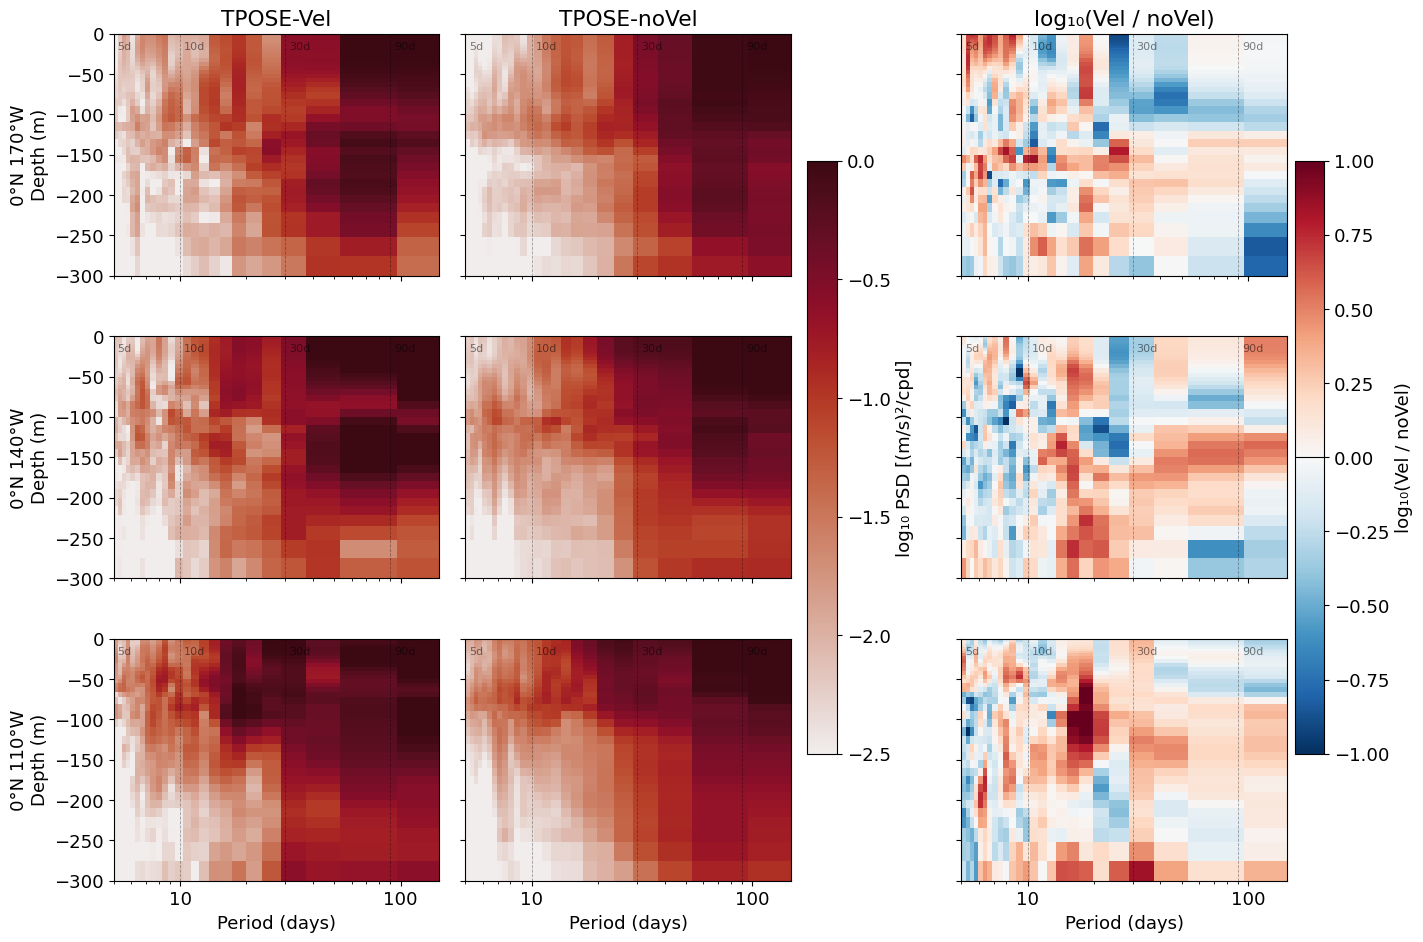

Saved tpose_spectrum_U.png


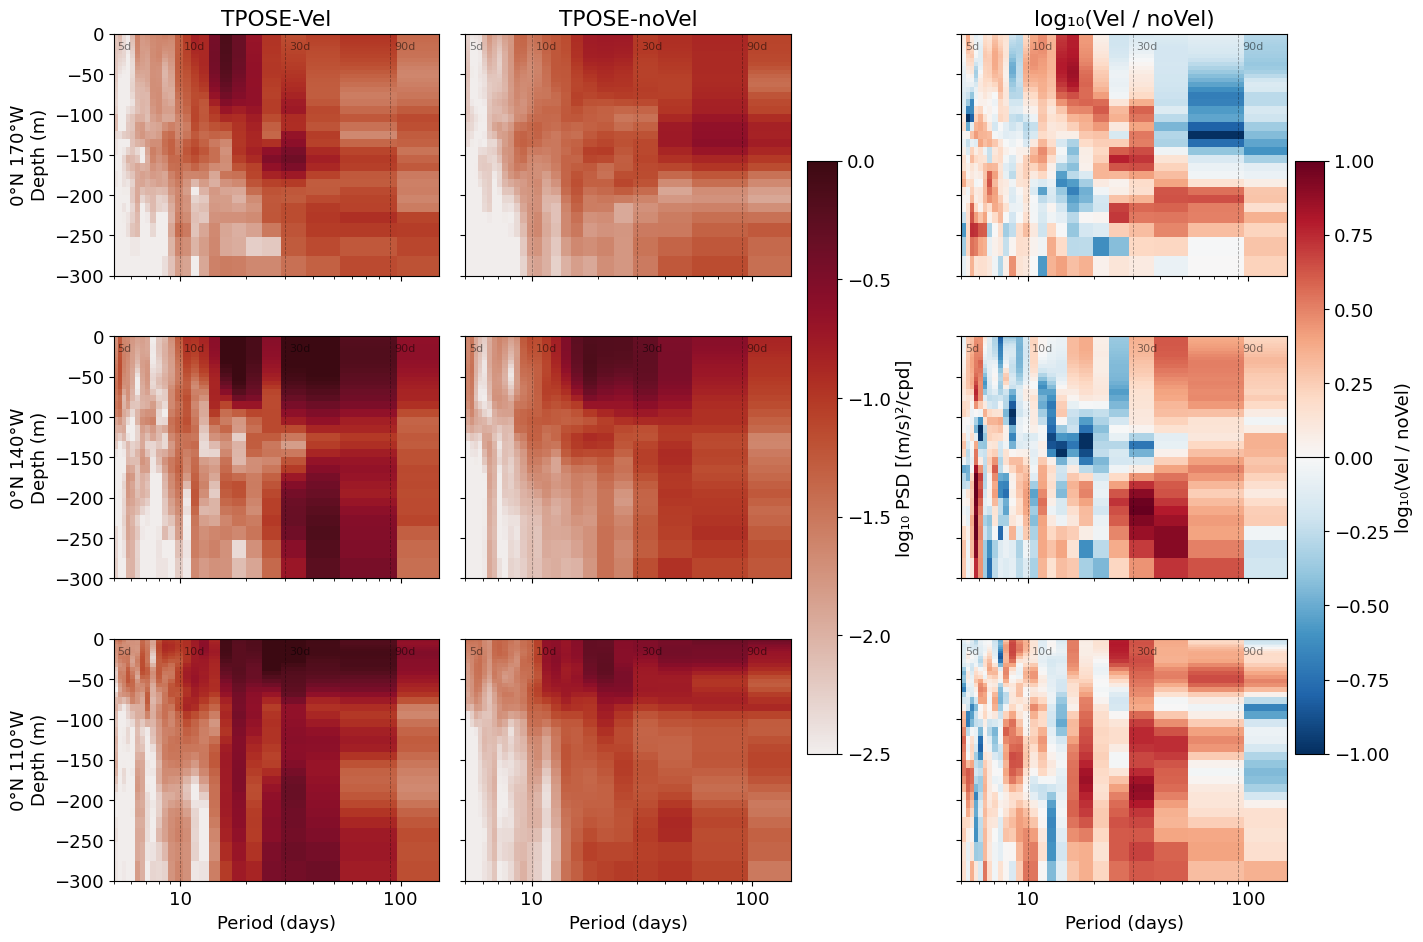

Saved tpose_spectrum_V.png


In [3]:
VMIN_PSD   = -2.5   # log10 PSD lower bound
VMAX_PSD   =  0.0   # log10 PSD upper bound
VMAX_RATIO = 1.0    # log10 ratio symmetric bound (±1.0 = factor of ~10)

REF_PERIODS = [(5, '5d'), (10, '10d'), (30, '30d'), (90, '90d')]

for var, varlabel in [('U', 'Zonal (U)'), ('V', 'Meridional (V)')]:
    fig, axes = plt.subplots(3, 3, figsize=(16, 11),
                             sharey=True, sharex=True)
    fig.subplots_adjust(hspace=0.25, wspace=0.08)

    psd_pcm   = None
    ratio_pcm = None

    for row, (lon_E, _) in enumerate(LOCS):
        res    = psd_results[var][lon_E]
        f      = res['freqs']
        f_mask = f > 0
        periods = 1.0 / f[f_mask]
        depths  = res['depths']

        psd_nV    = res['psd_noVel'][:, f_mask]
        psd_V     = res['psd_Vel'][:, f_mask]
        log_ratio = np.log10(psd_V) - np.log10(psd_nV)

        psd_pcm = axes[row, 0].pcolormesh(
            periods, depths, np.log10(psd_V),
            cmap=cmo.amp, vmin=VMIN_PSD, vmax=VMAX_PSD,
            shading='auto', rasterized=True)
        axes[row, 1].pcolormesh(
            periods, depths, np.log10(psd_nV),
            cmap=cmo.amp, vmin=VMIN_PSD, vmax=VMAX_PSD,
            shading='auto', rasterized=True)
        ratio_pcm = axes[row, 2].pcolormesh(
            periods, depths, log_ratio,
            cmap='RdBu_r', vmin=-VMAX_RATIO, vmax=VMAX_RATIO,
            shading='auto', rasterized=True)

        axes[row, 0].set_ylabel(f'{res["label"]}\nDepth (m)')

        for ax in axes[row]:
            for p, name in REF_PERIODS:
                ax.axvline(p, color='k', lw=0.6, ls='--', alpha=0.35)
                ax.text(p * 1.04, 0.97, name, fontsize=8, va='top', ha='left',
                        color='k', alpha=0.5, transform=ax.get_xaxis_transform())

    for ax in axes.flatten():
        ax.set_xscale('log')
        ax.set_xlim(5, 150)
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x)}'))

    for ax in axes[-1]:
        ax.set_xlabel('Period (days)')

    axes[0, 0].set_title('TPOSE-Vel')
    axes[0, 1].set_title('TPOSE-noVel')
    axes[0, 2].set_title('log\u2081\u2080(Vel / noVel)')

    cb1 = fig.colorbar(psd_pcm,
                       ax=axes[:, :2].ravel().tolist(),
                       label='log\u2081\u2080 PSD [(m/s)\u00b2/cpd]',
                       shrink=0.7, pad=0.02)
    cb2 = fig.colorbar(ratio_pcm,
                       ax=axes[:, 2].ravel().tolist(),
                       label='log\u2081\u2080(Vel / noVel)',
                       shrink=0.7, pad=0.02)
    cb2.ax.axhline(0, color='k', lw=0.8)

    fname = f'tpose_spectrum_{var}.png'
    plt.savefig(os.path.join(OUTDIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


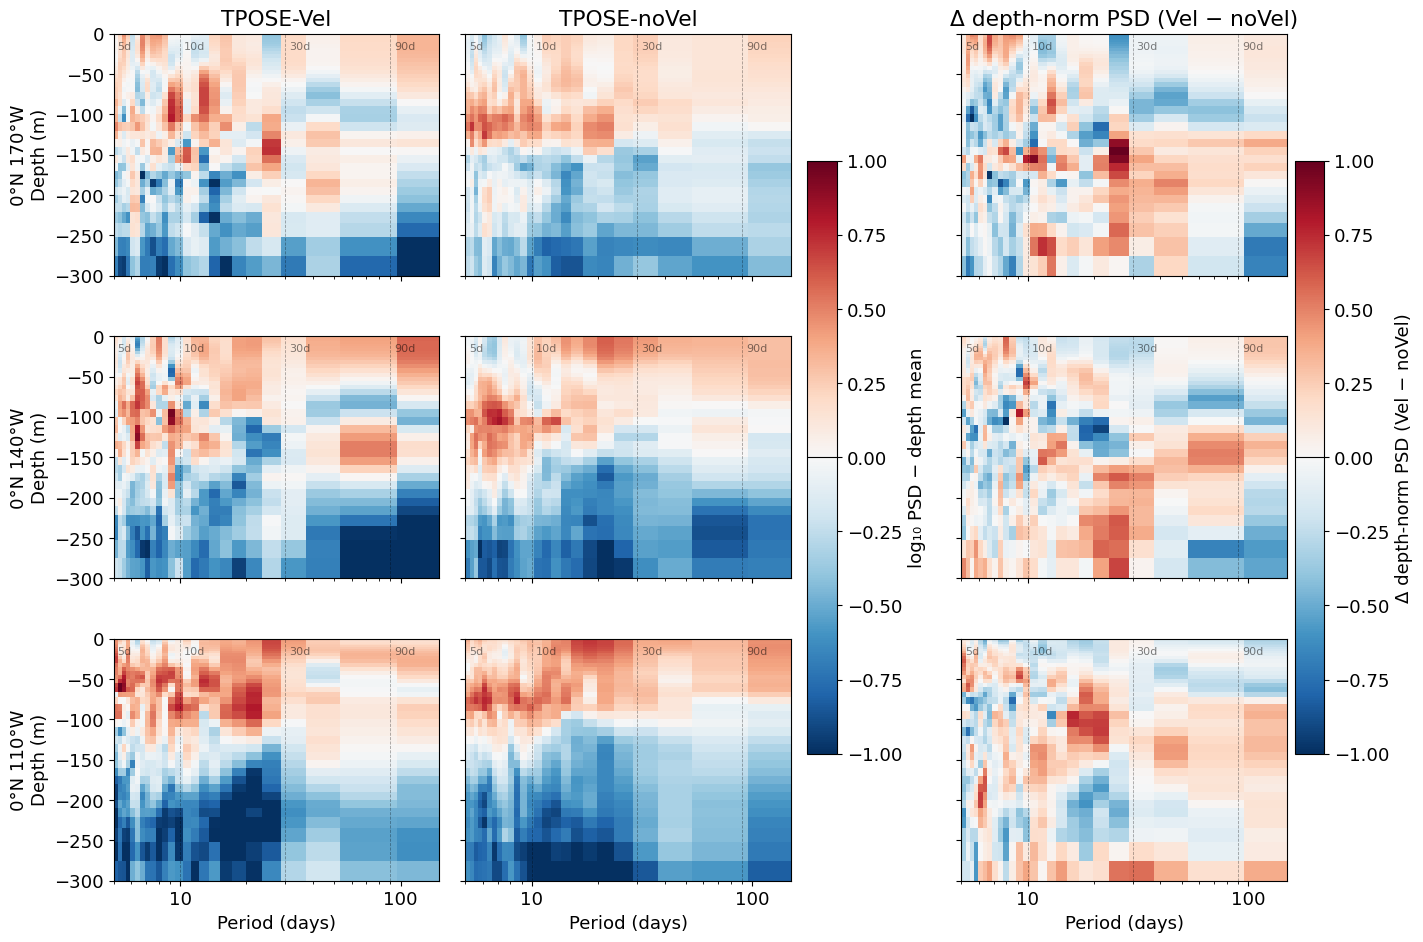

Saved tpose_spectrum_U_normdepth.png


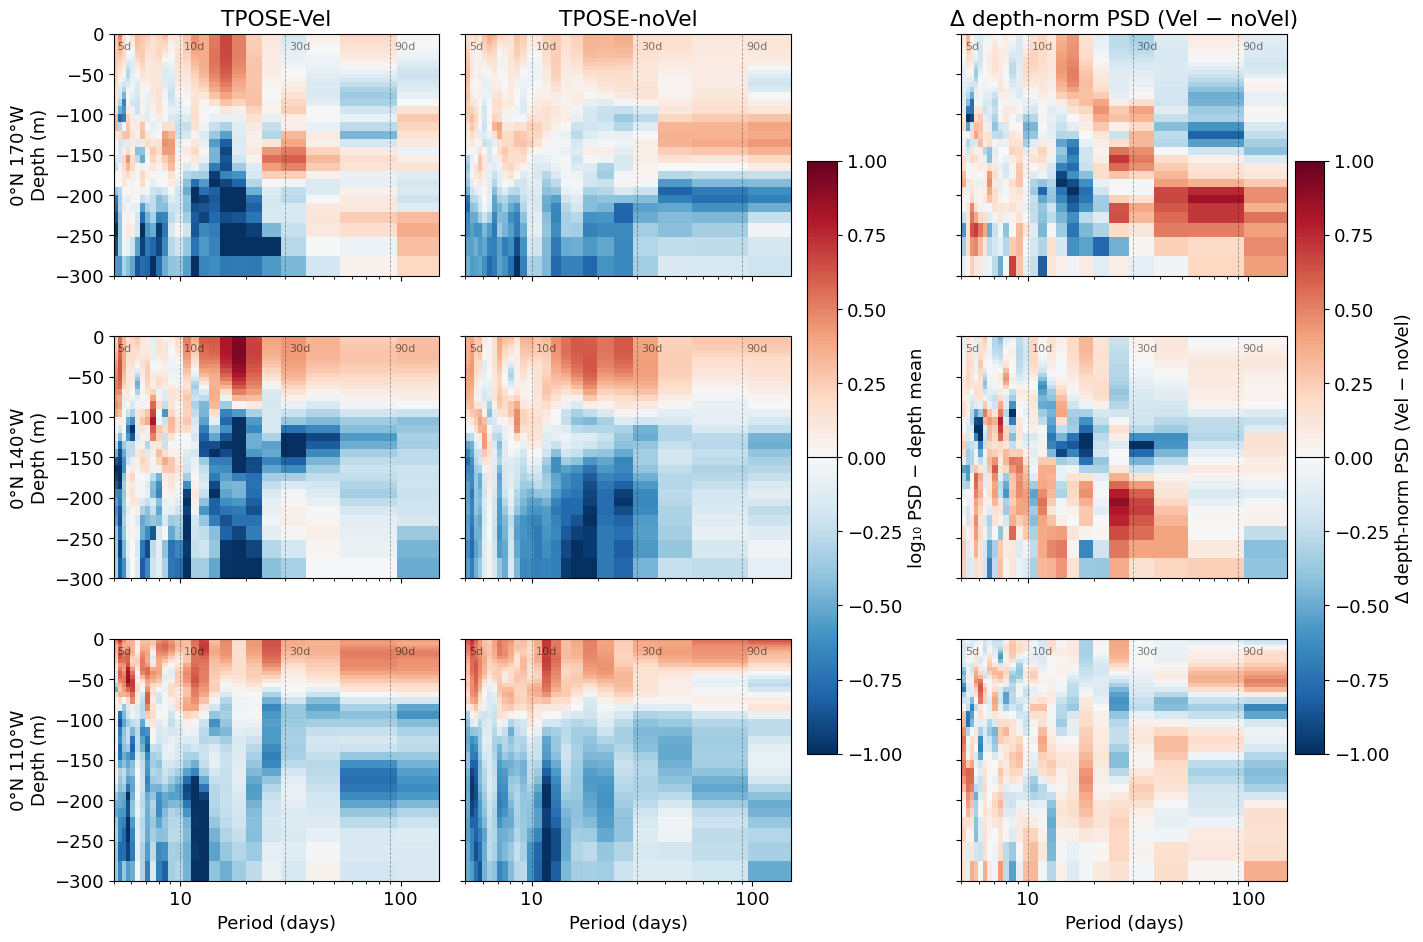

Saved tpose_spectrum_V_normdepth.png


In [4]:
## Depth-normalized PSD plots
# Subtract depth-mean log10 PSD at each period so colormap shows vertical structure

VMAX_NORM  = 1.0    # symmetric bound for depth-anomaly (log10 units)
VMAX_RATIO = 1.0

REF_PERIODS = [(5, '5d'), (10, '10d'), (30, '30d'), (90, '90d')]

for var, varlabel in [('U', 'Zonal (U)'), ('V', 'Meridional (V)')]:
    fig, axes = plt.subplots(3, 3, figsize=(16, 11),
                             sharey=True, sharex=True)
    fig.subplots_adjust(hspace=0.25, wspace=0.08)

    norm_pcm  = None
    ratio_pcm = None

    for row, (lon_E, _) in enumerate(LOCS):
        res    = psd_results[var][lon_E]
        f      = res['freqs']
        f_mask = f > 0
        periods = 1.0 / f[f_mask]
        depths  = res['depths']

        log_nV = np.log10(res['psd_noVel'][:, f_mask])
        log_V  = np.log10(res['psd_Vel'][:, f_mask])

        # Subtract depth-mean at each period
        anom_V  = log_V  - log_V.mean(axis=0, keepdims=True)
        anom_nV = log_nV - log_nV.mean(axis=0, keepdims=True)
        # Ratio of depth-normalized spectra
        norm_ratio = anom_V - anom_nV

        norm_pcm = axes[row, 0].pcolormesh(
            periods, depths, anom_V,
            cmap='RdBu_r', vmin=-VMAX_NORM, vmax=VMAX_NORM,
            shading='auto', rasterized=True)
        axes[row, 1].pcolormesh(
            periods, depths, anom_nV,
            cmap='RdBu_r', vmin=-VMAX_NORM, vmax=VMAX_NORM,
            shading='auto', rasterized=True)
        ratio_pcm = axes[row, 2].pcolormesh(
            periods, depths, norm_ratio,
            cmap='RdBu_r', vmin=-VMAX_RATIO, vmax=VMAX_RATIO,
            shading='auto', rasterized=True)

        axes[row, 0].set_ylabel(f'{res["label"]}\nDepth (m)')

        for ax in axes[row]:
            for p, name in REF_PERIODS:
                ax.axvline(p, color='k', lw=0.6, ls='--', alpha=0.35)
                ax.text(p * 1.04, 0.97, name, fontsize=8, va='top', ha='left',
                        color='k', alpha=0.5, transform=ax.get_xaxis_transform())

    for ax in axes.flatten():
        ax.set_xscale('log')
        ax.set_xlim(5, 150)
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x)}'))

    for ax in axes[-1]:
        ax.set_xlabel('Period (days)')

    axes[0, 0].set_title('TPOSE-Vel')
    axes[0, 1].set_title('TPOSE-noVel')
    axes[0, 2].set_title('\u0394 depth-norm PSD (Vel \u2212 noVel)')

    cb1 = fig.colorbar(norm_pcm,
                       ax=axes[:, :2].ravel().tolist(),
                       label='log\u2081\u2080 PSD \u2212 depth mean',
                       shrink=0.7, pad=0.02)
    cb1.ax.axhline(0, color='k', lw=0.8)
    cb2 = fig.colorbar(ratio_pcm,
                       ax=axes[:, 2].ravel().tolist(),
                       label='\u0394 depth-norm PSD (Vel \u2212 noVel)',
                       shrink=0.7, pad=0.02)
    cb2.ax.axhline(0, color='k', lw=0.8)

    fname = f'tpose_spectrum_{var}_normdepth.png'
    plt.savefig(os.path.join(OUTDIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')


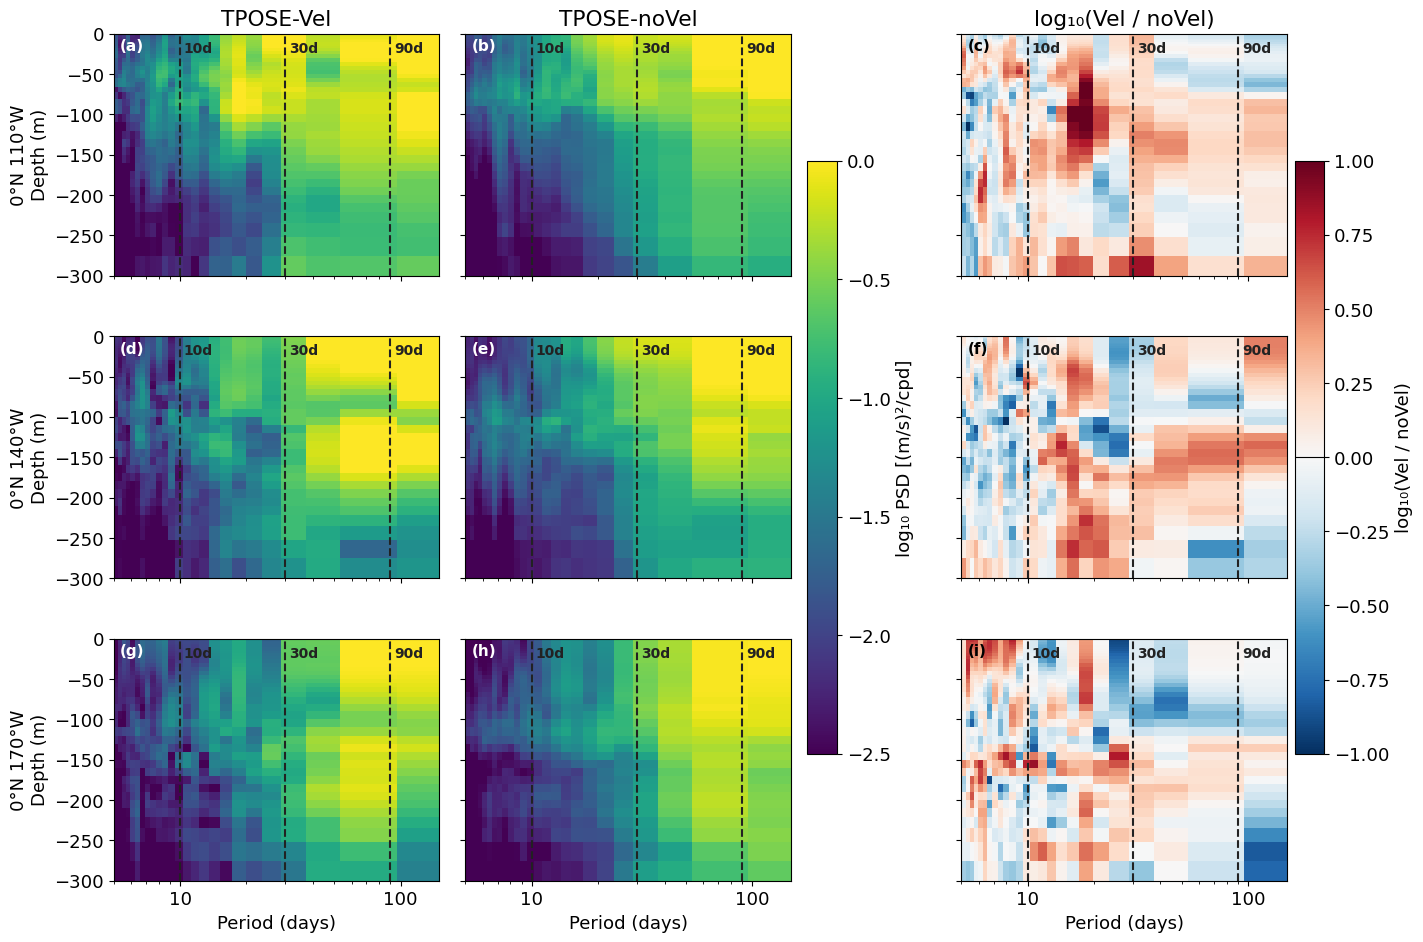

Saved tpose_spectrum_U_viridis.png


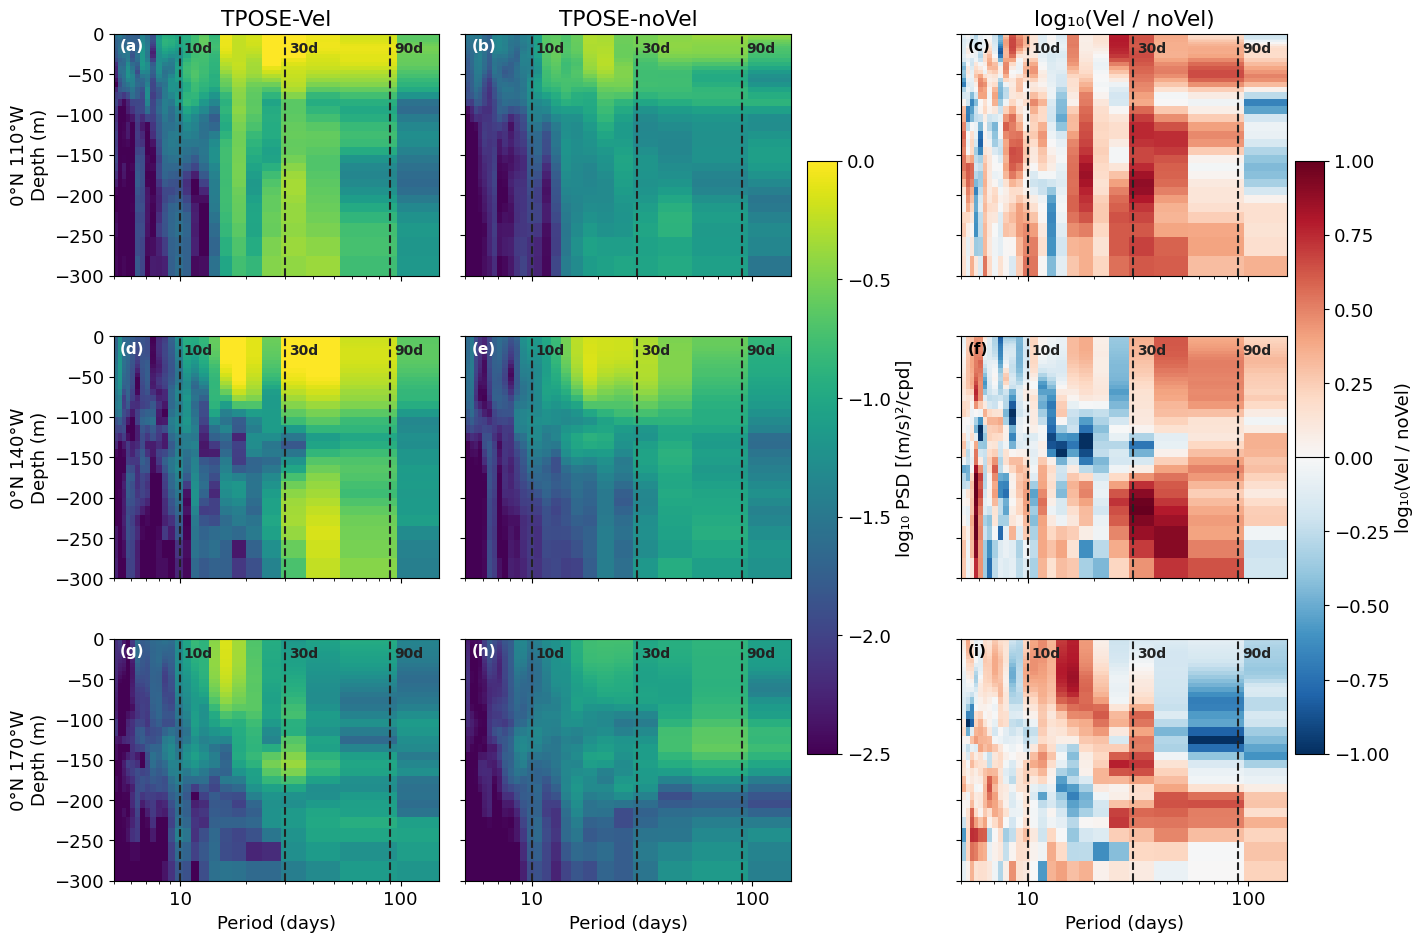

Saved tpose_spectrum_V_viridis.png


In [5]:
## Viridis colormap version of the regular PSD plots

VMIN_PSD   = -2.5
VMAX_PSD   =  0.0
VMAX_RATIO = 1.0

REF_PERIODS = [(10, '10d'), (30, '30d'), (90, '90d')]
LOCS_PLOT   = list(reversed(LOCS))  # 110W top, 140W middle, 170W bottom

for var, varlabel in [('U', 'Zonal (U)'), ('V', 'Meridional (V)')]:
    fig, axes = plt.subplots(3, 3, figsize=(16, 11),
                             sharey=True, sharex=True)
    fig.subplots_adjust(hspace=0.25, wspace=0.08)

    psd_pcm   = None
    ratio_pcm = None

    for row, (lon_E, _) in enumerate(LOCS_PLOT):
        res    = psd_results[var][lon_E]
        f      = res['freqs']
        f_mask = f > 0
        periods = 1.0 / f[f_mask]
        depths  = res['depths']

        psd_nV    = res['psd_noVel'][:, f_mask]
        psd_V     = res['psd_Vel'][:, f_mask]
        log_ratio = np.log10(psd_V) - np.log10(psd_nV)

        psd_pcm = axes[row, 0].pcolormesh(
            periods, depths, np.log10(psd_V),
            cmap='viridis', vmin=VMIN_PSD, vmax=VMAX_PSD,
            shading='auto', rasterized=True)
        axes[row, 1].pcolormesh(
            periods, depths, np.log10(psd_nV),
            cmap='viridis', vmin=VMIN_PSD, vmax=VMAX_PSD,
            shading='auto', rasterized=True)
        ratio_pcm = axes[row, 2].pcolormesh(
            periods, depths, log_ratio,
            cmap='RdBu_r', vmin=-VMAX_RATIO, vmax=VMAX_RATIO,
            shading='auto', rasterized=True)

        axes[row, 0].set_ylabel(f'{res["label"]}\nDepth (m)')

        for ax in axes[row]:
            for p, name in REF_PERIODS:
                ax.axvline(p, color='#222222', lw=1.5, ls='--')
                ax.text(p * 1.04, 0.97, name, fontsize=10, va='top', ha='left',
                        color='#222222', transform=ax.get_xaxis_transform(),
                        fontweight='bold')

    for ax in axes.flatten():
        ax.set_xscale('log')
        ax.set_xlim(5, 150)
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: f'{int(x)}'))

    for ax in axes[-1]:
        ax.set_xlabel('Period (days)')

    axes[0, 0].set_title('TPOSE-Vel')
    axes[0, 1].set_title('TPOSE-noVel')
    axes[0, 2].set_title('log\u2081\u2080(Vel / noVel)')

    for idx, ax in enumerate(axes.flatten()):
        label_color = 'k' if idx % 3 == 2 else 'white'
        ax.text(0.02, 0.98, f'({chr(ord("a") + idx)})', transform=ax.transAxes,
                fontsize=11, fontweight='bold', va='top', ha='left', color=label_color)

    cb1 = fig.colorbar(psd_pcm,
                       ax=axes[:, :2].ravel().tolist(),
                       label='log\u2081\u2080 PSD [(m/s)\u00b2/cpd]',
                       shrink=0.7, pad=0.02)
    cb2 = fig.colorbar(ratio_pcm,
                       ax=axes[:, 2].ravel().tolist(),
                       label='log\u2081\u2080(Vel / noVel)',
                       shrink=0.7, pad=0.02)
    cb2.ax.axhline(0, color='k', lw=0.8)

    fname = f'tpose_spectrum_{var}_viridis.png'
    plt.savefig(os.path.join(OUTDIR, fname), dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {fname}')
